# Redução de dimensionalidade - Parte I - Revisão de Álgebra Linear


## Memes de hoje (há infinitos sobre essa temática)

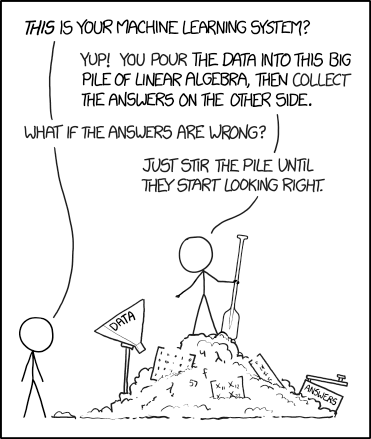

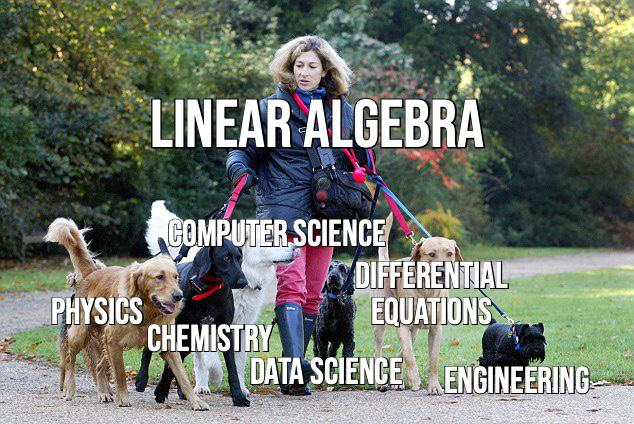

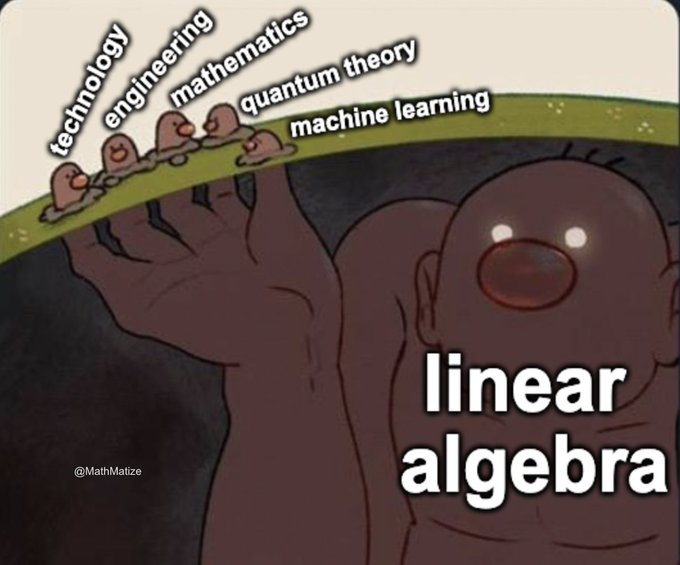

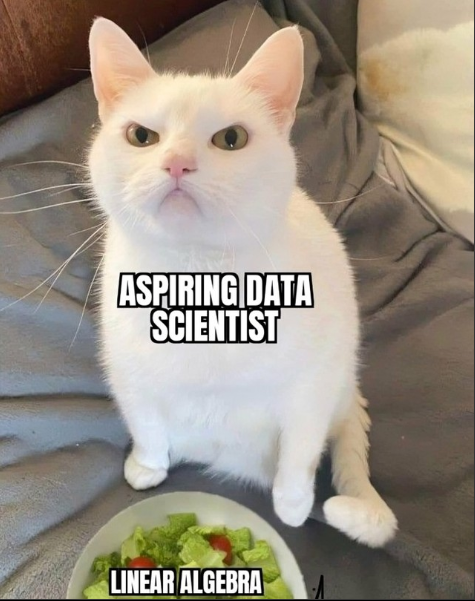

O conteúdo da aula de hoje foi baseado em:
1. https://github.com/mcrovella/CS506-Computational-Tools-for-Data-Science
2. https://github.com/mcrovella/CS132-Geometric-Algorithms
3. Considerações do professor

**WARNING:** em muitas partes da aula de hoje, estarei cometendo "abuso" de notação e simplificação. Para um tratamento formal, recomendo a referência 1, acima.

## Introdução

Da aula passada...

Em muitas situações, o conjunto de dados de interesse pode ser visto como uma matriz com $n$ linhas e $d$ colunas.

As linhas representam objetos (e.g., pessoas) e as colunas os atributos (e.g., peso, altura, idade, etc.).

$$\mathbf{X} = \begin{bmatrix}
    x_{11} & x_{12} & x_{13} & \dots  & x_{1d} \\
    x_{21} & x_{22} & x_{23} & \dots  & x_{2d} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    x_{n1} & x_{n2} & x_{n3} & \dots  & x_{nd}
\end{bmatrix}
$$

O que acontece quando $n$ e $d$ são muito grandes?

1. Há um problema relacionado ao armazenamento e à eficiência algorítmica.

2. Maldição da dimensionalidade.

**O que fazer então?** Redução de dimensionalidade!

A ideia básica de redução de dimensionalidade é encontrar maneiras de representar os objetos do conjunto de dados (linhas da matriz $\mathbf{X}$) utilizando menos colunas (i.e., um número menor de dimensões) perdendo o mínimo possível de **informação**.

Esse objetivo pode gerar várias perguntas:
- no contexto dado, o que significa **informação**?
- Como fazer?

Apesar de estarmos vendo esse problema no contexto de Ciência de Dados, responder as perguntas acima é basicamente uma aplicação de Álgebra Linear.


## Vetores e Matrizes

Uma **matriz** é um *array* retangular de números, por exemplo:

$$\mathbf{X} = \left[\begin{array}{rrr}
    1  & -2  & 1 \\
    0 & 2 &  - 8 \\
    6 & 5 &9
\end{array}
\right]$$


Uma matriz com apenas uma coluna é chamada de **vetor coluna**, ou simplesmente **vetor**.

Abaixo, alguns exemplos.

Esses são vetores no $\mathbb{R}^2$:
$$
\begin{array}{ccc}
{\bf u} = \left[\begin{array}{r}3\\-1\end{array}\right] &
{\bf v} = \left[\begin{array}{c}.2\\.3\end{array}\right] &
{\bf w} = \left[\begin{array}{c}w_1\\w_2\end{array}\right]
\end{array}
$$


e esses são vetores no $\mathbb{R}^3$:

$$
\begin{array}{ccc}
{\bf u} = \left[\begin{array}{c}2\\3\\4\end{array}\right] &
{\bf v} = \left[\begin{array}{r}-1\\0\\2\end{array}\right] &
{\bf w} = \left[\begin{array}{c}w_1\\w_2\\w_3\end{array}\right]
\end{array}
$$

Nós usaremos letras maiúsculas em negrito ($\mathbf{X}$) para matrizes e letras minúsculas em negrito para vetores ($\mathbf{u}$).

Se
$$\begin{align}
    \mathbf{x} &= \begin{bmatrix}
           x_{1} \\
           x_{2} \\
           \vdots \\
           x_{d}
         \end{bmatrix},
  \end{align}$$
então também é comum escrever $\mathbf{x} = [x_1\; \dots\; x_d]^T$ para simplificar e economizar espaço. O "*T*" significa Transposto.

É comum visualizar vetores como pontos no espaço.

In [ ]:
#@title
!wget https://raw.githubusercontent.com/mcrovella/CS506-Computational-Tools-for-Data-Science/refs/heads/master/laUtilities.py
!pip install qrcode
import matplotlib.pyplot as plt

--2025-11-03 21:02:30--  https://raw.githubusercontent.com/mcrovella/CS506-Computational-Tools-for-Data-Science/refs/heads/master/laUtilities.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48472 (47K) [text/plain]
Saving to: ‘laUtilities.py.1’

laUtilities.py.1    100%[===================>]  47.34K  --.-KB/s    in 0.01s   

2025-11-03 21:02:30 (4.63 MB/s) - ‘laUtilities.py.1’ saved [48472/48472]



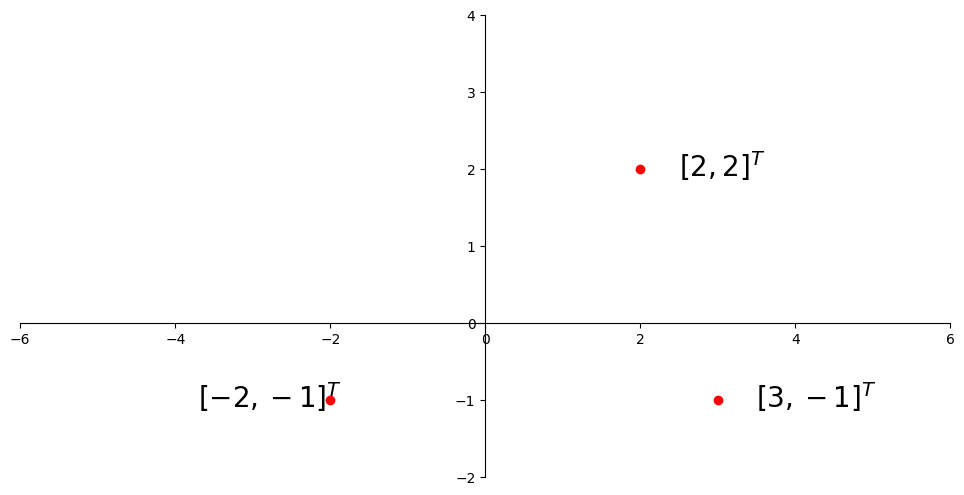

In [ ]:
#@title
import laUtilities as ut
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ut.plotPoint(ax, -2, -1)
ut.plotPoint(ax, 2, 2)
ut.plotPoint(ax, 3, -1)
ax.plot(0, -2, '')
ax.plot(-4, 0, '')
ax.text(3.5, -1.1, '$[3,-1]^T$', size=20)
ax.text(2.5, 1.9, '$[2,2]^T$', size=20)
ax.text(-3.7, -1.1, '$[-2,-1]^T$', size=20);


Também é comum desenharmos vetores como "setas". Essa visualização vem da física e é bem útil em muitas situações.

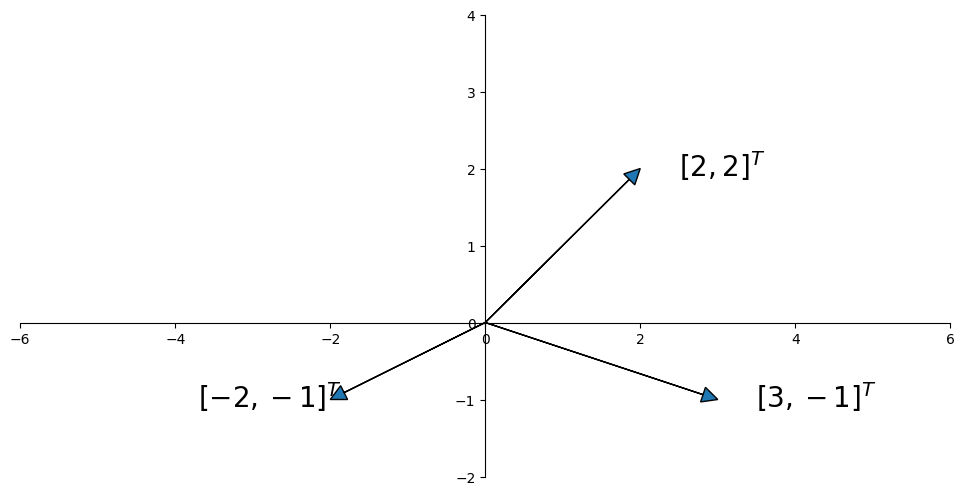

In [ ]:
#@title
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ax.arrow(0, 0, -2, -1, head_width=0.2, head_length=0.2, length_includes_head = True)
ax.arrow(0, 0, 2, 2, head_width=0.2, head_length=0.2, length_includes_head = True)
ax.arrow(0, 0, 3, -1, head_width=0.2, head_length=0.2, length_includes_head = True)
ax.plot(0, -2, '')
ax.plot(-4, 0, '')
ax.plot(0, 2, '')
ax.plot(4 ,0, '')
ax.text(3.5, -1.1, '$[3,-1]^T$', size=20)
ax.text(2.5, 1.9, '$[2,2]^T$', size=20)
ax.text(-3.7, -1.1, '$[-2,-1]^T$', size=20);

## Adição de vetores

Se
$$\begin{align}
    \mathbf{x} &= \begin{bmatrix}
           x_{1} \\
           x_{2} \\
           \vdots \\
           x_{d}
         \end{bmatrix},
  \end{align}$$
e
$$\begin{align}
    \mathbf{y} &= \begin{bmatrix}
           y_{1} \\
           y_{2} \\
           \vdots \\
           y_{d}
         \end{bmatrix},
  \end{align}$$
então
$$\begin{align}
    \mathbf{x}+\mathbf{y} &= \begin{bmatrix}
           x_{1} + y_{1} \\
           x_{2} + y_{2}\\
           \vdots \\
           x_{d} + y_{d}
         \end{bmatrix}.
  \end{align}$$
Em outras palavras, a adição é feita componente por componente dos vetores.


Uma interpretação geométrica da soma de vetores é como um paralelogramo.  
Se ${\bf u}$ e ${\bf v}$ em $\mathbb{R}^2$ são representados como pontos no plano, então ${\bf u} + {\bf v}$ corresponde ao quarto vértice do paralelogramo cujos outros vértices são ${\bf u}$, $0$, e ${\bf v}$.


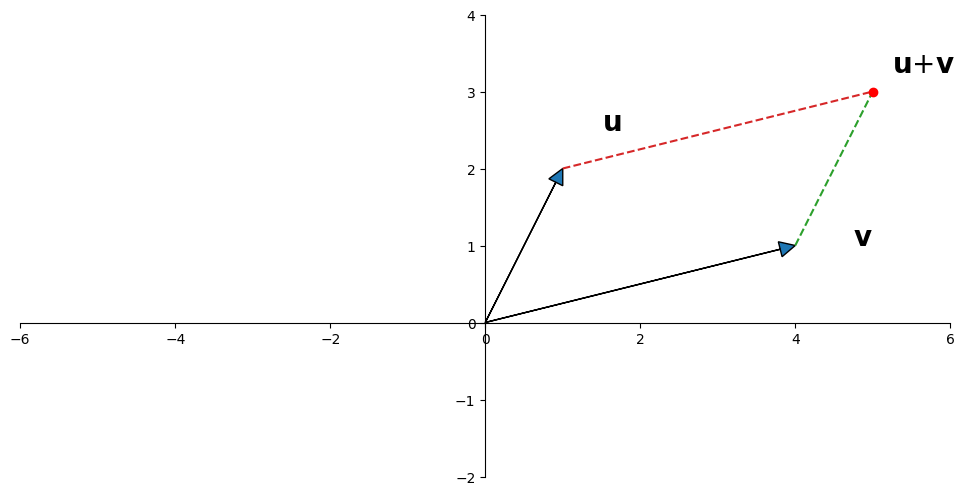

In [ ]:
#@title
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ax.arrow(0, 0, 1, 2, head_width=0.2, head_length=0.2, length_includes_head = True)
ax.arrow(0, 0, 4, 1, head_width=0.2, head_length=0.2, length_includes_head = True)
ax.plot([4,5],[1,3],'--')
ax.plot([1,5],[2,3],'--')
ax.text(5.25,3.25,r'${\bf u}$+${\bf v}$',size=20)
ax.text(1.5,2.5,r'${\bf u}$',size=20)
ax.text(4.75,1,r'${\bf v}$',size=20)
ut.plotPoint(ax,5,3)
ax.plot(0,0,'');

Assim, podemos, informalmente, pensar que os vetores somados estão sendo "encadeados" uns com os outros, como mostra a figura abaixo.

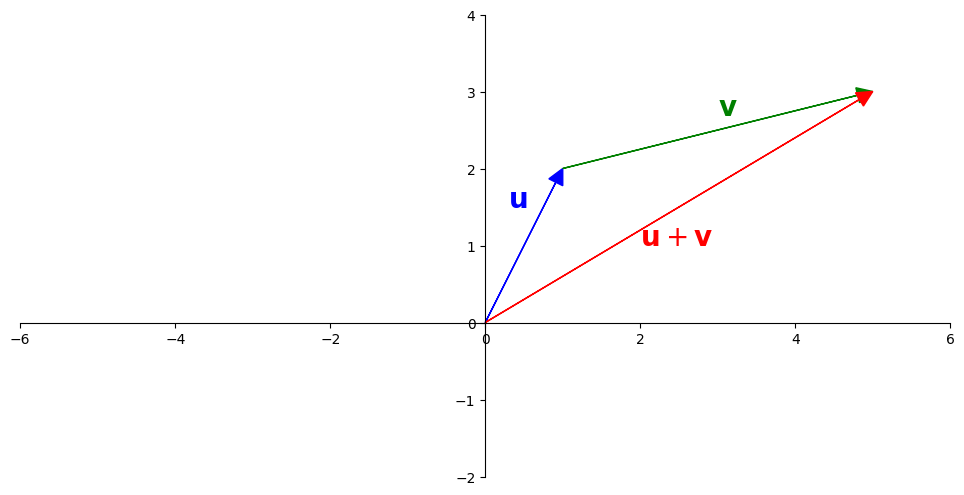

In [ ]:
#@title
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ax.arrow(0, 0, 1, 2, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'blue')
ax.arrow(1, 2, 4, 1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'green')
ax.arrow(0, 0, 5, 3, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'red')
ax.text(.3,1.5,r'${\bf u}$',size=20, color = 'blue')
ax.text(3,2.7,r'${\bf v}$',size=20, color = 'green')
ax.text(2,1,r'${\bf u} + {\bf v}$',size=20, color = 'red');

A subtração de dois vetores pode ser definida e representada em função da adição.

Tem-se que $\mathbf{u} - \mathbf{v} = \mathbf{u} + (\mathbf{-v})$. As duas figuras abaixo mostram a interpretação geométrica da subtração.

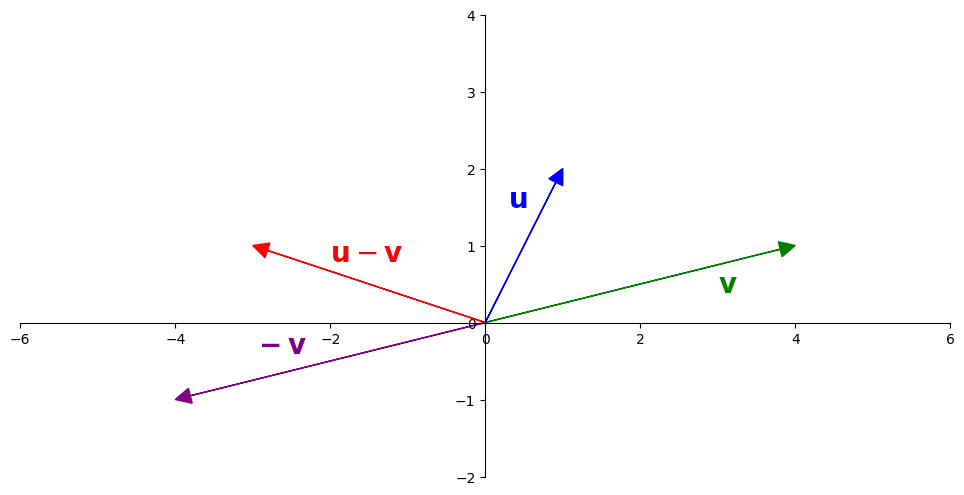

In [ ]:
#@title
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ax.arrow(0, 0, 1, 2, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'blue')
ax.arrow(0, 0, 4, 1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'green')
ax.arrow(0, 0, -4, -1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'purple')
ax.arrow(0, 0, -3, 1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'red')
ax.text(.3,1.5,r'${\bf u}$',size=20, color = 'blue')
ax.text(3,0.4,r'${\bf v}$',size=20, color = 'green')
ax.text(-3,-0.4,r'${\bf -v}$',size=20, color = 'purple')
ax.text(-2,0.8,r'${\bf u} - {\bf v}$',size=20, color = 'red');

Outra forma de visualizar a subtração é dada abaixo.

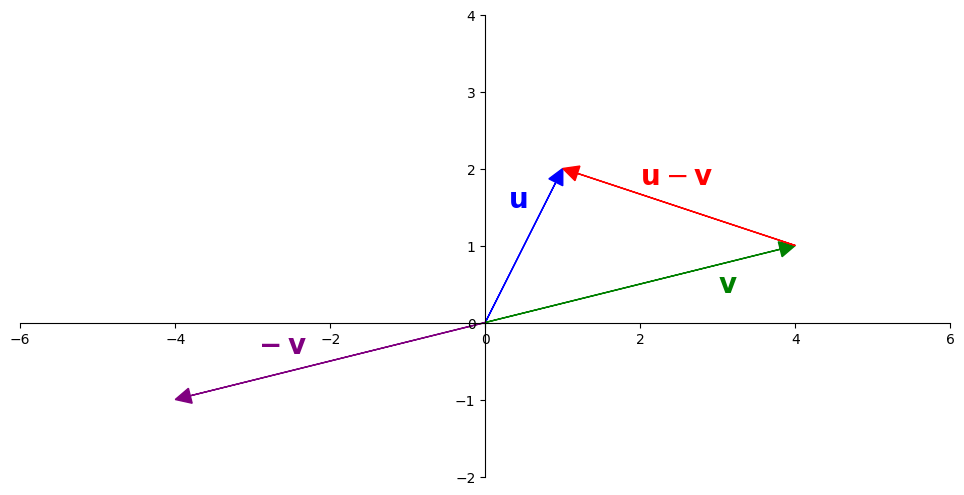

In [ ]:
#@title
ax = ut.plotSetup(size=(12,6))
ut.centerAxes(ax)
ax.arrow(0, 0, 1, 2, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'blue')
ax.arrow(0, 0, 4, 1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'green')
ax.arrow(0, 0, -4, -1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'purple')
ax.arrow(4, 1, -3, 1, head_width=0.2, head_length=0.2, length_includes_head = True, color = 'red')
ax.text(.3,1.5,r'${\bf u}$',size=20, color = 'blue')
ax.text(3,0.4,r'${\bf v}$',size=20, color = 'green')
ax.text(-3,-0.4,r'${\bf -v}$',size=20, color = 'purple')
ax.text(2,1.8,r'${\bf u} - {\bf v}$',size=20, color = 'red');

## Multiplicação de matrizes

Se
$$\mathbf{X} = \begin{bmatrix}
    x_{11} & x_{12} & x_{13} & \dots  & x_{1d} \\
    x_{21} & x_{22} & x_{23} & \dots  & x_{2d} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    x_{n1} & x_{n2} & x_{n3} & \dots  & x_{nd}
\end{bmatrix}
$$
e
$$\mathbf{Y} = \begin{bmatrix}
    y_{11} & y_{12} & y_{13} & \dots  & y_{1m} \\
    y_{21} & y_{22} & y_{23} & \dots  & y_{2m} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    y_{d1} & y_{d2} & y_{d3} & \dots  & y_{dm}
\end{bmatrix},
$$
então $\mathbf{Z} = \mathbf{X}\mathbf{Y}$ é tal que $z_{ij}$, elemento da $i$-ésima linha e $j$-ésima coluna de $\mathbf{Z}$, é dado por:
$$z_{ij} = \sum_{k = 1}^dx_{ik}y_{kj}.$$

Assim, para calcular $z_{ij}$ precisamos de todos os elementos da linha $i$ de $\mathbf{X}$ e da coluna $j$ de $\mathbf{Y}$.

Do mais, veja que o número de colunas de $\mathbf{X}$ dever ser igual ao número de linhas de $\mathbf{Y}$. Além disso, o número de linhas de $\mathbf{Z}$ será o número de linhas de $\mathbf{X}$ e o número de colunas de $\mathbf{Z}$ será o número de colunas de $\mathbf{Y}$.

##Produto (interno) entre vetores

Se
$$\begin{align}
    \mathbf{x} &= \begin{bmatrix}
           x_{1} \\
           x_{2} \\
           \vdots \\
           x_{d}
         \end{bmatrix},
  \end{align}$$
e
$$\begin{align}
    \mathbf{y} &= \begin{bmatrix}
           y_{1} \\
           y_{2} \\
           \vdots \\
           y_{d}
         \end{bmatrix},
  \end{align}$$
então o produto escalar (ou interno) entre $\mathbf{x}$ e $\mathbf{y}$ é dado por
$$\mathbf{x}\cdot\mathbf{y} = \sum_{i = 1}^dx_iy_i.$$

Veja que:
$$\mathbf{y}\cdot\mathbf{x} = \mathbf{x}\cdot\mathbf{y} =
\begin{bmatrix}
           x_{1}\;
           x_{2}\;
           \cdots\;
           x_{d}
    \end{bmatrix}
\begin{bmatrix}
           y_{1} \\
           y_{2} \\
           \vdots \\
           y_{d}
\end{bmatrix}
=\mathbf{x}^T\mathbf{y} =\mathbf{y}^T\mathbf{x}.  
$$

A notação de produto interno com notação matricial é importante! Vamos utilizá-la com frequência.

## Norma de um vetor

Se $\mathbf{v}$ está em $\mathbb{R}^n$, com entradas $v_1, \dots, v_n$, então a raiz quadrada de $\mathbf{v}^T \mathbf{v}$ é bem definida porque $\mathbf{v}^T \mathbf{v}$ é não negativo.


__Definição.__ A __norma $\ell_2$__ de $\mathbf{v}$ é o escalar não negativo $\Vert\mathbf{v}\Vert_2$ definido por

$$\Vert\mathbf{v}\Vert_2 = \sqrt{\mathbf{v}^T\mathbf{v}} = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2} = \sqrt{\sum_{i=1}^n v_i^2}.$$

Se omitirmos o subscrito $_2$, ele é subentendido.


A norma ($\ell_2$) de $\mathbf{v}$ é o seu __comprimento__ no sentido usual.

Isso decorre diretamente do teorema de Pitágoras:

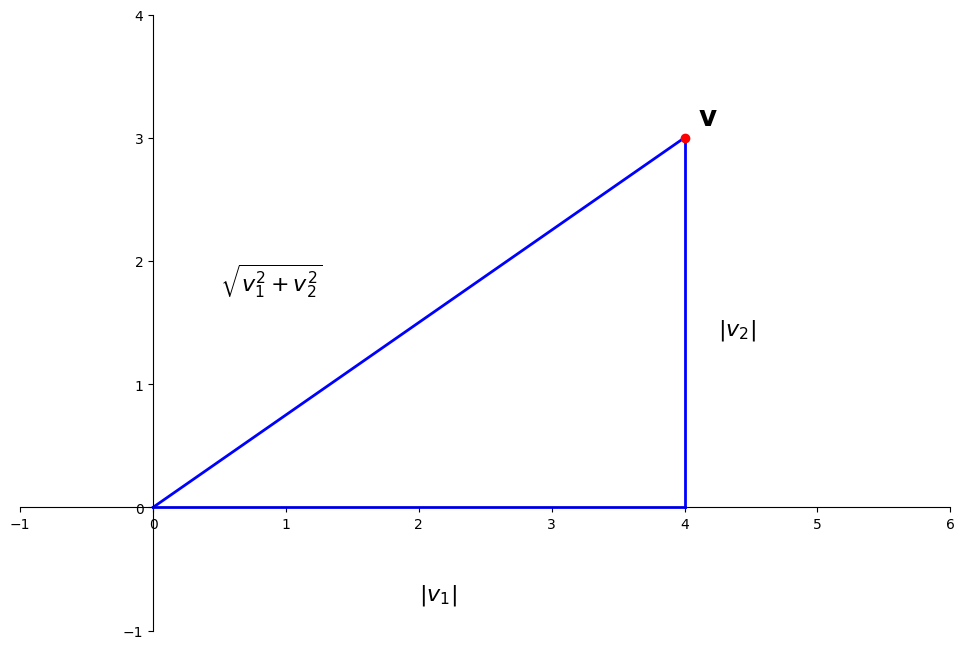

In [ ]:
#@title
ax = ut.plotSetup(-1,6,-1,4,(12,8))
ut.centerAxes(ax)
pt = [4., 3.]
plt.plot([0,pt[0]],[0,pt[1]],'b-',lw=2)
plt.plot([pt[0],pt[0]],[0,pt[1]],'b-',lw=2)
plt.plot([0,pt[0]],[0,0],'b-',lw=2)
ut.plotVec(ax,pt)
ax.text(2,-0.75,r'$|v_1|$',size=16)
ax.text(4.25,1.4,r'$|v_2|$',size=16)
ax.text(0.5,1.75,r'$\sqrt{v_1^2+v_2^2}$',size=16)
ax.text(pt[0]+0.1,pt[1]+0.1,r'$\mathbf{v}$',size=20);

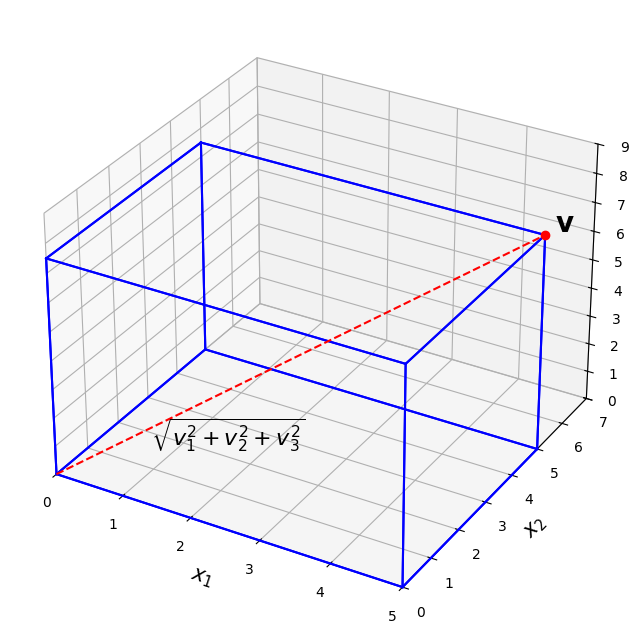

In [ ]:
#@title
ax = ut.plotSetup3d(0,5,0,7,0,9,(12,8))
f = 1.25
v = [4*f,4*f,6*f]
ut.plotCube(ax,v)
ax.text(v[0]+.1,v[1]+.1,v[2]+.1,r'$\bf v$',size=20)
ax.plot([0,v[0]],[0,v[1]],'r--',zs=[0,v[2]])
ax.plot([v[0]],[v[1]],'ro',zs=[v[2]])
ax.text(0.5,2,-0.5,r'$\sqrt{v_1^2+v_2^2+v_3^2}$',size=16);

Um vetor de comprimento 1 é chamado de __vetor unitário__.
  

Se dividirmos um vetor não nulo $\mathbf{v}$ pelo seu comprimento — ou seja, multiplicarmos por $1/\Vert\mathbf{v}\Vert$ — obtemos um vetor unitário $\mathbf{u}$.

Dizemos que $\mathbf{v}$ foi _normalizado_ e que $\mathbf{u}$ está _na mesma direção_ que $\mathbf{v}$.

## Distância no $\mathbb{R}^n$



É muito útil poder falar sobre a __distância__ entre dois pontos (ou vetores) em $\mathbb{R}^n$.

__Definição.__ Para $\mathbf{u}$ e $\mathbf{v}$ em $\mathbb{R}^n$, a __distância entre $\mathbf{u}$ e $\mathbf{v}$__, escrita como $\mbox{dist}(\mathbf{u},\mathbf{v})$, é o comprimento do vetor $\mathbf{u}-\mathbf{v}$. Ou seja,

$$\mbox{dist}(\mathbf{u},\mathbf{v}) = \Vert\mathbf{u}-\mathbf{v}\Vert.$$

Esta definição concorda com as fórmulas usuais para a distância Euclidiana entre dois pontos. A fórmula usual é

$$\mbox{dist}(\mathbf{u},\mathbf{v}) = \sqrt{(v_1-u_1)^2 + (v_2-u_2)^2 + \dots + (v_n-u_n)^2}.$$

O que você pode ver que é igual a

$$\Vert\mathbf{u}-\mathbf{v}\Vert = \sqrt{(\mathbf{u}-\mathbf{v})^T(\mathbf{u}-\mathbf{v})} = \sqrt{\left[\begin{array}{cccc}u_1-v_1 & u_2-v_2 & \dots & u_n-v_n\end{array}\right]\left[\begin{array}{c}u_1-v_1\\u_2-v_2\\\vdots\\u_n-v_n\end{array}\right]}.$$


Existe outra reformulação importante da distância. Considere a distância ao quadrado:

$$\Vert\mathbf{u}-\mathbf{v}\Vert^2 = (\mathbf{u}-\mathbf{v})^T(\mathbf{u}-\mathbf{v})$$


Expandindo isso, obtemos:

$$\Vert\mathbf{u}-\mathbf{v}\Vert^2 = \mathbf{u}^T\mathbf{u} + \mathbf{v}^T\mathbf{v} - 2\mathbf{u}^T\mathbf{v}.$$

$$= \Vert\mathbf{u}\Vert^2 + \Vert\mathbf{v}\Vert^2 - 2\mathbf{u}^T\mathbf{v}.$$


Esta é uma fórmula importante porque relaciona a __distância__ entre dois pontos com seus __comprimentos__ e __produto interno__.

## Vetores ortogonais

Agora passamos a outro conceito familiar da geometria 2D, que vamos generalizar para $\mathbb{R}^n$: a noção de ser __perpendicular.__

Geralmente, usaremos o termo mais sofisticado __ortogonal__ — que significa a mesma coisa que perpendicular.


Diremos que dois vetores são ortogonais se eles formarem um ângulo reto na origem.


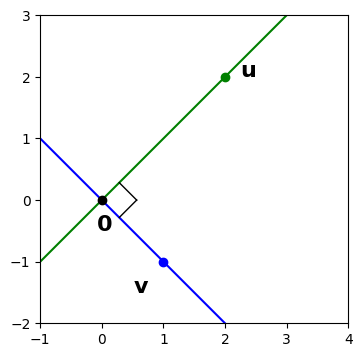

In [ ]:
#@title
import numpy as np
ax = ut.plotSetup(-1,4,-2,3)
ax.set_aspect('equal')
# ut.noAxes(ax)
u = np.array([2, 2])
v = np.array([1, -1])
# v
ut.plotLinEqn(u[0], u[1], 0, '-', 'b')
ut.plotLinEqn(v[0], v[1], 0, '-', 'g')
ax.text(v[0]-0.5,v[1]-0.5,r'$\bf v$',size=16)
ut.plotVec(ax,v,'b')
# u
ut.plotVec(ax,u,'g')
ax.text(u[0]+0.25,u[1],r'$\bf u$',size=16)
# origin
ut.plotVec(ax, np.array([0, 0]), 'k')
ax.text(0-0.1, 0-0.5, r'$\bf 0$', size=16);
# symbol
perpline1, perpline2 = ut.perp_sym(np.array([0, 0]), u, v, 0.4)
plt.plot(perpline1[0], perpline1[1], 'k', lw = 1)
plt.plot(perpline2[0], perpline2[1], 'k', lw = 1);

Desenhe a linha conectando $\mathbf{u}$ e $\mathbf{v}$ à origem.

Então, $\mathbf{u}$ e $\mathbf{v}$ são ortogonais se e somente se formarem um triângulo retângulo com a origem.

Portanto, $\mathbf{u}$ e $\mathbf{v}$ são ortogonais se e somente se o Teorema de Pitágoras for satisfeito para este triângulo.


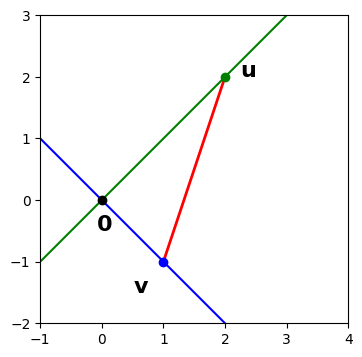

In [ ]:
#@title
ax = ut.plotSetup(-1,4,-2,3)
ax.set_aspect('equal')
# ut.noAxes(ax)
u = np.array([2, 2])
v = np.array([1, -1])
plt.plot([v[0],u[0]],[v[1],u[1]],'r-',lw=2)
# v
ut.plotLinEqn(u[0], u[1], 0, '-', 'b')
ut.plotLinEqn(v[0], v[1], 0, '-', 'g')
ax.text(v[0]-0.5,v[1]-0.5,r'$\bf v$',size=16)
ut.plotVec(ax,v,'b')
# u
ut.plotVec(ax,u,'g')
ax.text(u[0]+0.25,u[1],r'$\bf u$',size=16)
# origin
ut.plotVec(ax, np.array([0, 0]), 'k')
ax.text(0-0.1, 0-0.5, r'$\bf 0$', size=16);

Qual é o comprimento do lado vermelho do triângulo?

De acordo com a definição de comprimento baseada na norma, é $\Vert \mathbf{u} - \mathbf{v} \Vert$.

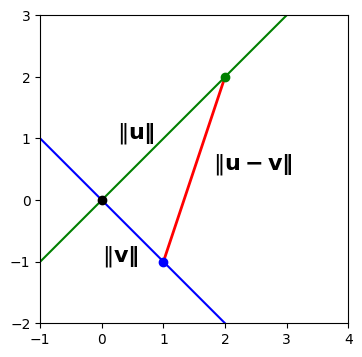

In [ ]:
#@title
ax = ut.plotSetup(-1,4,-2,3)
ax.set_aspect('equal')
# ut.noAxes(ax)
u = np.array([2, 2])
v = np.array([1, -1])
plt.plot([v[0],u[0]],[v[1],u[1]],'r-',lw=2)
# v
ut.plotLinEqn(u[0], u[1], 0, '-', 'b')
ut.plotLinEqn(v[0], v[1], 0, '-', 'g')
ax.text(v[0]/2-0.5,v[1]/2-0.5,r'$\Vert\bf v\Vert$',size=16)
ut.plotVec(ax,v,'b')
# u
ut.plotVec(ax,u,'g')
ax.text(u[0]/2-.75,u[1]/2,r'$\Vert\bf u\Vert$',size=16)
# origin
ut.plotVec(ax, np.array([0, 0]), 'k')
#
mm = (u + v) / 2
ax.text(mm[0]+0.3,mm[1],r'$\Vert\bf u - v\Vert$',size=16);

Portanto, as linhas azul e verde são perpendiculares temos:

$$ \Vert \mathbf{u} - \mathbf{v} \Vert^2 = \Vert \mathbf{u} \Vert^2 + \Vert \mathbf{v} \Vert^2 $$

Primeiro, vamos simplificar a expressão para a distância ao quadrado de $\mathbf{u}$ a $\mathbf{v}$:

$$ \Vert\mathbf{u}-\mathbf{v}\Vert^2 = (\mathbf{u}-\mathbf{v})^T(\mathbf{u}-\mathbf{v}) $$

$$ = \mathbf{u}^T\mathbf{u} - \mathbf{u}^T\mathbf{v} - \mathbf{v}^T\mathbf{u} + \mathbf{v}^T\mathbf{v}$$

$$ = \Vert\mathbf{u}\Vert^2 + \Vert\mathbf{v}\Vert^2 - 2\mathbf{u}^T\mathbf{v}$$

Agora, voltemos ao Teorema de Pitágoras.  

$\mathbf{u}$ e $\mathbf{v}$ são perpendiculares se e somente se:

$$ \Vert \mathbf{u} - \mathbf{v} \Vert^2 = \Vert \mathbf{u} \Vert^2 + \Vert \mathbf{v} \Vert^2.$$

Mas, então vimos que isso significa que:

$$ \Vert\mathbf{u}\Vert^2 + \Vert\mathbf{v}\Vert^2 - 2\mathbf{u}^T\mathbf{v}= \Vert \mathbf{u} \Vert^2 + \Vert \mathbf{v} \Vert^2$$

Agora podemos definir perpendicularidade em $\mathbb{R}^n$:

__Definição.__ Dois vetores $\mathbf{u}$ e $\mathbf{v}$ em $\mathbb{R}^n$ são __ortogonais__ entre si se $\mathbf{u}^T\mathbf{v} = 0.$


Isso nos dá uma regra muito simples para determinar se dois vetores são ortogonais: se e somente se seu produto interno for zero.

## O Ângulo entre dois vetores

Existe uma conexão adicional entre o produto interno de dois vetores e o __ângulo__ entre eles.

Essa conexão é muito útil (por exemplo, para visualizar operações de mineração de dados).

Começamos pela __lei dos cossenos:__

$$ c^2 = a^2 + b^2 - 2ab\cos\theta $$


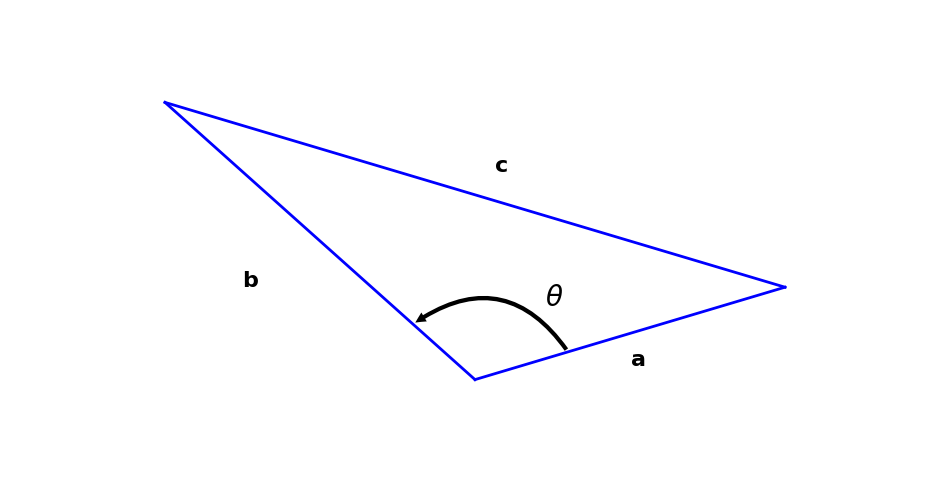

In [ ]:
#@title
ax = ut.plotSetup(-6,6,-1,4,(12,6))
u = np.array([4.,1])
v = np.array([-4.,3])
pt = u + v
plt.plot([u[0],v[0]],[u[1],v[1]],'b-',lw=2)
plt.plot([0,u[0]],[0,u[1]],'b-',lw=2)
plt.plot([0,v[0]],[0,v[1]],'b-',lw=2)
m = (u-v)/2.0
mm = v + m
ax.text(mm[0]+0.25,mm[1]+0.25,r'${\bf c}$',size=16)
ax.text(2,0.15,r'${\bf a}$',size=16)
ax.text(-3,1,r'${\bf b}$',size=16)
ax.annotate('', xy=(0.2*v[0], 0.2*v[1]),  xycoords='data',
                xytext=(0.3*u[0], 0.3*u[1]), textcoords='data',
                size=15,
                #bbox=dict(boxstyle="round", fc="0.8"),
                arrowprops={'arrowstyle': 'simple',
                                'fc': '0',
                                'ec': 'none',
                                'connectionstyle' : 'arc3,rad=0.5'},
                )
ax.text(0.9,0.8,r'$\theta$',size=20)
plt.axis('off');

Agora, vamos interpretar essa lei em termos dos vetores $\mathbf{u}$ e $\mathbf{v}$.

Mais uma vez, estamos interessados no ângulo que esses vetores formam na origem:

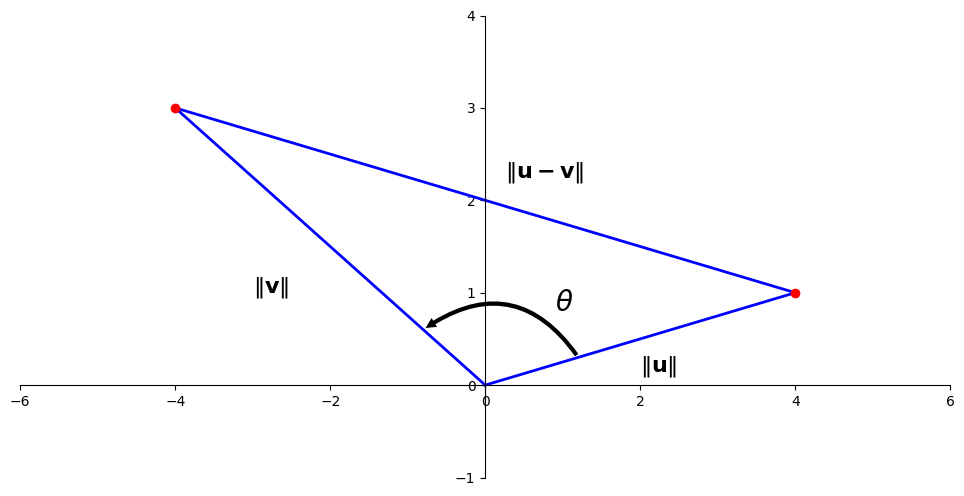

In [ ]:
#@title
ax = ut.plotSetup(-6,6,-1,4,(12,6))
ut.centerAxes(ax)
u = np.array([4.,1])
v = np.array([-4.,3])
pt = u + v
plt.plot([u[0],v[0]],[u[1],v[1]],'b-',lw=2)
plt.plot([0,u[0]],[0,u[1]],'b-',lw=2)
plt.plot([0,v[0]],[0,v[1]],'b-',lw=2)
ut.plotVec(ax,u)
ut.plotVec(ax,v)
m = (u-v)/2.0
mm = v + m
ax.text(mm[0]+0.25,mm[1]+0.25,r'$\Vert{\bf u-v}\Vert$',size=16)
ax.text(2,0.15,r'$\Vert{\bf u}\Vert$',size=16)
ax.text(-3,1,r'$\Vert{\bf v}\Vert$',size=16)
ax.annotate('', xy=(0.2*v[0], 0.2*v[1]),  xycoords='data',
                xytext=(0.3*u[0], 0.3*u[1]), textcoords='data',
                size=15,
                #bbox=dict(boxstyle="round", fc="0.8"),
                arrowprops={'arrowstyle': 'simple',
                                'fc': '0',
                                'ec': 'none',
                                'connectionstyle' : 'arc3,rad=0.5'},
                )
ax.text(0.9,0.8,r'$\theta$',size=20);

Aplicando a lei dos cossenos, temos:
    
$$\Vert\mathbf{u}-\mathbf{v}\Vert^2 = \Vert\mathbf{u}\Vert^2 + \Vert\mathbf{v}\Vert^2 - 2\Vert\mathbf{u}\Vert\Vert\mathbf{v}\Vert\cos\theta$$

E por definição:

$$ \Vert\mathbf{u}-\mathbf{v}\Vert^2 = \Vert\mathbf{u}\Vert^2 + \Vert\mathbf{v}\Vert^2 - 2\mathbf{u}^T\mathbf{v}$$

Logo

$$ \mathbf{u}^T\mathbf{v} = \Vert\mathbf{u}\Vert\Vert\mathbf{v}\Vert\cos\theta$$

Esta é uma conexão __muito__ importante entre a noção de produto interno e a trigonometria.


Uma implicação em particular diz respeito aos __vetores unitários.__

$$ \mathbf{u}^T\mathbf{v} = \Vert\mathbf{u}\Vert\Vert\mathbf{v}\Vert\cos\theta $$

Logo

$$ \frac{\mathbf{u}^T\mathbf{v}}{\Vert\mathbf{u}\Vert\Vert\mathbf{v}\Vert} = \cos\theta$$

$$ \frac{\mathbf{u}^T}{\Vert\mathbf{u}\Vert}\frac{\mathbf{v}}{\Vert\mathbf{v}\Vert} = \cos\theta$$

Assim, temos uma regra muito simples: para dois vetores unitários, seu produto interno é o cosseno do ângulo entre eles!

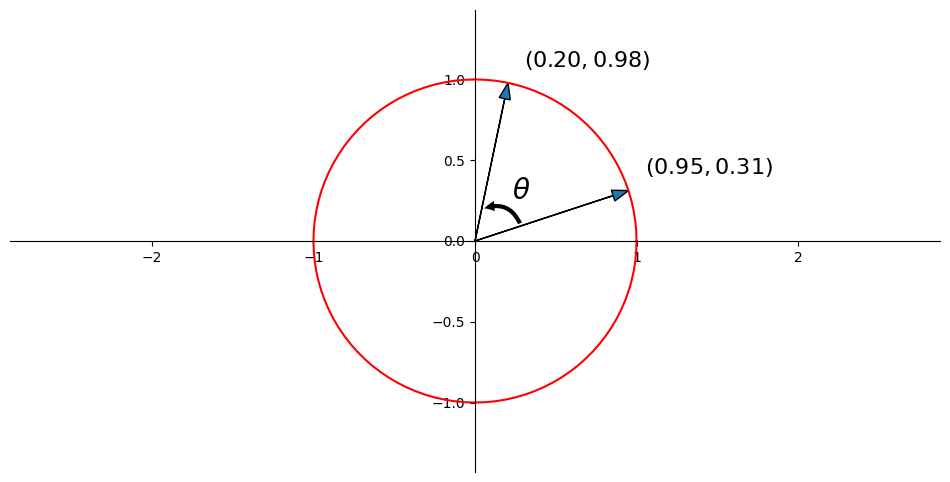

In [ ]:
#@title
u = np.array([0.95, np.sin(np.arccos(0.95))])
theta = (np.pi/3)+np.arccos(0.95)
v = np.array([np.cos(theta), np.sin(theta)])
ax = ut.plotSetup(-1.3,1.3,-1.3,1.3,(12,6))
ut.centerAxes(ax)
plt.axis('equal')
angles = 2.0*np.pi * np.array(range(101))/100.0
plt.plot(np.cos(angles),np.sin(angles),'r-')
ax.arrow(0,0,u[0],u[1],head_width=0.07, head_length=0.1,length_includes_head = True)
ax.arrow(0,0,v[0],v[1],head_width=0.07, head_length=0.1,length_includes_head = True)
ax.annotate('', xy=(0.2*v[0], 0.2*v[1]),  xycoords='data',
                xytext=(0.3*u[0], 0.3*u[1]), textcoords='data',
                size=15,
                #bbox=dict(boxstyle="round", fc="0.8"),
                arrowprops={'arrowstyle': 'simple',
                                'fc': '0',
                                'ec': 'none',
                                'connectionstyle' : 'arc3,rad=0.5'})
mid = 0.4*(u+v)/2.0
ax.text(mid[0],mid[1],r'$\theta$',size=20)
ax.text(u[0]+.1,u[1]+.1,r'$(%0.2f,%0.2f)$'% (u[0],u[1]),size=16)
ax.text(v[0]+.1,v[1]+.1,r'$(%0.2f,%0.2f)$'% (v[0],v[1]),size=16);

Aqui $\mathbf{u} = \left[\begin{array}{c}0.95\\0.31\end{array}\right]$ e $\mathbf{v} = \left[\begin{array}{c}0.20\\0.98\end{array}\right].$

Assim, $\mathbf{u}^T\mathbf{v} = 0.5$

Assim, $\cos\theta = 0.5.$

Portanto, $\theta = 60$ graus.

## Exercício - Projeção ortogonal

Considere o exemplo abaixo. Quando fazemos a **projeção ortogonal** do vetor $\mathbf{w}$ sobre o vetor $\mathbf{z}$, obtemos o vetor $\text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}}$.

**Pergunta:** quem é $\text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}}$ em função de $\mathbf{w}$ e $\mathbf{z}$?

In [ ]:
#@title
def orthogonal_projection(x, y):
  alpha = np.dot(x, y) / np.dot(y, y)
  return alpha * y

def plot_vector(v, color, org = np.array([0, 0]), zorder = 0, alpha = 0.8):
  plt.quiver(org[0], org[1], v[0], v[1],
       color = color,
       zorder = 10, alpha = alpha, width = 0.013, angles='xy', scale_units='xy', scale=1)

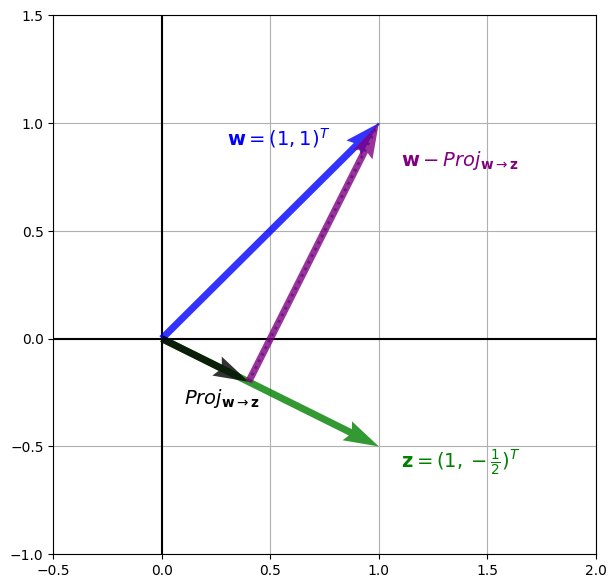

In [ ]:
z = np.array([1, -0.5])
w = np.array([1, 1])

proj_wz = orthogonal_projection(w, z)

diff = w - proj_wz
plt.figure(figsize = (7, 7))
plot_vector(z, "green")
plot_vector(w, "blue")

plt.plot([-10, 10], [0, 0], color = 'black')
plt.plot([0, 0], [-10, 10], color = 'black')
plt.annotate(r'$\mathbf{z} = (1, -\frac{1}{2})^T$', xy=z, xytext=z+[0.1, -0.1], size = 14, color = 'green')
plt.annotate(r'$\mathbf{w} = (1, 1)^T$', xy=z, xytext=w+[-0.7, -0.1], size = 14, color = 'blue')
plt.grid(True)
plt.xlim((-0.5, 2))
plt.ylim((-1, 1.5));

# 2
plt.plot([proj_wz[0], w[0]], [proj_wz[1], w[1]], linestyle = ':', linewidth = 2)

# 3
plot_vector(proj_wz, "black")
plt.annotate(r'$Proj_{\mathbf{w}\rightarrow\mathbf{z}}$', xy=proj_wz, xytext=proj_wz+[-0.3, -0.1], size = 14)

# 4
plot_vector(diff, "purple", org = proj_wz)
plt.annotate(r'$\mathbf{w} - Proj_{\mathbf{w}\rightarrow\mathbf{z}}$', xy=w - proj_wz, xytext=w - proj_wz+[0.5, -0.4], size = 14, color = 'purple');

Como $\text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}}$ está na mesma direção de $\mathbf{z}$, temos
$$\text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}} = \alpha \mathbf{z}.$$
Além disso, sabemos que
$\mathbf{z}$ e $\mathbf{w} - \text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}}$ são ortogonais. Logo

$$\mathbf{z}^T(\mathbf{w} - \text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}}) = 0.$$
Logo
$$\mathbf{z}^T(\mathbf{w} - \alpha\mathbf{z}) = 0.$$
Resolvendo a equação acima para $\alpha$, temos
$$\alpha = \frac{\mathbf{z}^T\mathbf{w}}{\mathbf{z}^T\mathbf{z}}.$$
Assim
$$\text{Proj}_{\mathbf{w}\rightarrow\mathbf{z}} = \frac{\mathbf{z}^T\mathbf{w}}{\mathbf{z}^T\mathbf{z}}\mathbf{z}.$$


## (In)Dependência Linear

Um conjunto de vetores $\{{\bf v_1, ..., v_p}\}$, todos em $\mathbb{R}^n$, é dito <font color=blue>_linearmente dependente_</font> se existirem pesos $\{c_1, ..., c_p\}$, __não todos nulos__, tais que

$$c_1{\bf v_1} + ... + c_p{\bf v_p} = {\bf 0}.$$


Por outro lado, o conjunto $\{{\bf v_1, ..., v_p}\}$ é dito <font color=blue>_linearmente independente_</font> se a equação vetorial

$$c_1{\bf v_1} + ... + c_p{\bf v_p} = {\bf 0}$$

tiver apenas a solução __trivial__ $c_1 = 0, ..., c_p = 0$.


Exemplos?

## Transformações

Uma __transformação__ (ou __função__ ou __aplicação__) $T$ de $\mathbb{R}^n$ em $\mathbb{R}^m$ é uma regra que associa a cada vetor ${\bf x}$ em $\mathbb{R}^n$ um vetor $T({\bf x})$ em $\mathbb{R}^m$.


O conjunto $\mathbb{R}^n$ é chamado de __domínio__ de $T$, e $\mathbb{R}^m$ é chamado de __contradomínio__ de $T$.  

A notação:

$$ T: \mathbb{R}^n \rightarrow \mathbb{R}^m $$

indica que o domínio de $T$ é $\mathbb{R}^n$ e o contradomínio é $\mathbb{R}^m$.


Vamos fazer um exemplo. Suponha que temos estes pontos em $\mathbb{R}^2$:

$$
\left[\begin{array}{r}0\\1\end{array}\right], \quad
\left[\begin{array}{r}1\\1\end{array}\right], \quad
\left[\begin{array}{r}1\\0\end{array}\right], \quad
\left[\begin{array}{r}0\\0\end{array}\right]
$$

Onde esses pontos estão localizados?

Eles correspondem aos vértices de um quadrado unitário no primeiro quadrante do plano cartesiano, com cantos nos pontos $(0,0)$, $(1,0)$, $(1,1)$ e $(0,1)$.

In [ ]:
#@title
!wget https://raw.githubusercontent.com/mcrovella/CS132-Geometric-Algorithms/refs/heads/master/demoUtilities.py
import demoUtilities as dm

--2025-11-03 21:02:49--  https://raw.githubusercontent.com/mcrovella/CS132-Geometric-Algorithms/refs/heads/master/demoUtilities.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3091 (3.0K) [text/plain]
Saving to: ‘demoUtilities.py.1’

demoUtilities.py.1  100%[===================>]   3.02K  --.-KB/s    in 0s      

2025-11-03 21:02:49 (39.8 MB/s) - ‘demoUtilities.py.1’ saved [3091/3091]



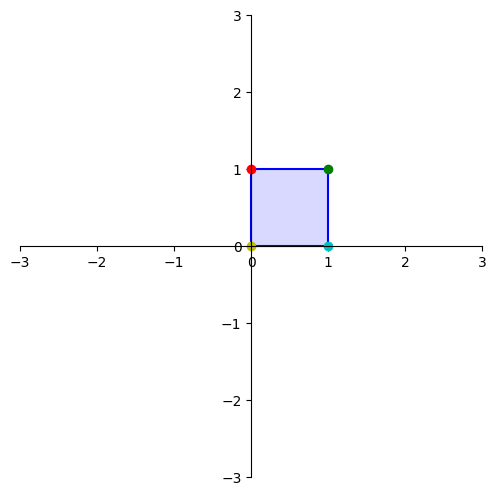

In [ ]:
#@title
square = np.array([[0, 1, 1, 0],
                   [1, 1, 0, 0]])
dm.plotSetup()
dm.plotSquare(square);

Agora, vamos transformar cada um desses pontos de acordo com a seguinte regra. Seja

$$ A = \left[\begin{array}{rr}1 & 1.5\\ 0 & 1\end{array}\right]. $$

Definimos $T({\bf x}) = A{\bf x}$. Então temos

$$ T: \mathbb{R}^2 \rightarrow \mathbb{R}^2. $$


Temos:

$$ A\left[\begin{array}{r}0\\1\end{array}\right] = \left[\begin{array}{r}1.5\\1\end{array}\right]$$


$$ A\left[\begin{array}{r}1\\1\end{array}\right] = \left[\begin{array}{r}2.5\\1\end{array}\right]$$


$$ A\left[\begin{array}{r}1\\0\end{array}\right] = \left[\begin{array}{r}1\\0\end{array}\right]$$


$$ A\left[\begin{array}{r}0\\0\end{array}\right] = \left[\begin{array}{r}0\\0\end{array}\right]$$

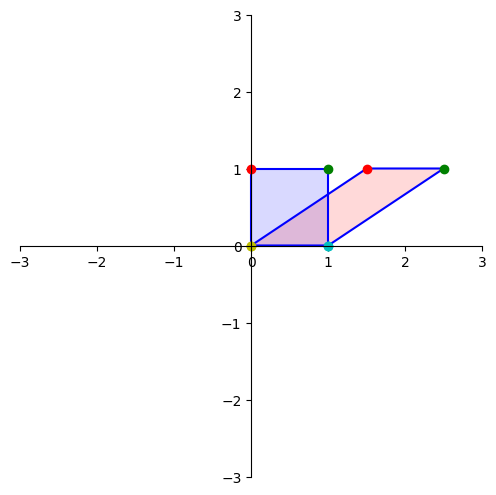

In [ ]:
#@title
ax = dm.plotSetup()
dm.plotSquare(square)
#
# create the A matrix
A = np.array([[1.0, 1.5],[0.0,1.0]])
#
# apply the shear matrix to the square
ssquare = np.zeros(np.shape(square))
for i in range(4):
    ssquare[:,i] = dm.AxVS(A,square[:,i])
dm.plotSquare(ssquare,'r');

Esse tipo de transformação, em que os pontos são sucessivamente deslocados lateralmente, é chamado de transformação de __cisalhamento__ (ou __shear__).

### Transformações Lineares

__Definição.__ Uma transformação $T$ é __linear__ se:
1. $T({\bf u} + {\bf v}) = T({\bf u}) + T({\bf v}) \;\;\;$ para todos os vetores ${\bf u}, {\bf v}$ no domínio de $T$; e  
2. $T(s{\bf u}) = sT({\bf u}) \;\;\;$ para todo escalar $s$ e todo vetor ${\bf u}$ no domínio de $T$.


### Exemplo I

Pelas propriedades da multiplicação matriz-vetor, sabemos que a transformação ${\bf x} \mapsto \mathbf{A}{\bf x}$ possui as propriedades

$$ \mathbf{A}({\bf u} + {\bf v}) = \mathbf{A}{\bf u} + \mathbf{A}{\bf v} \;\;\;\mbox{e}\;\;\; \mathbf{A}(s{\bf u}) = s\mathbf{A}{\bf u} $$

para todos os vetores ${\bf u}, {\bf v}$ em $\mathbb{R}^n$ e todos os escalares $s$.
Logo, essa é uma transformação linear!


### Exemplo II

Seja $T(\mathbf{x}) = \mathbf{x} + \mathbf{b}$ para algum $\mathbf{b} \neq 0$.   

Que tipo de operação $T$ implementa?

Essa transformação representa uma __translação__ (ou deslocamento).  
Cada vetor $\mathbf{x}$ é movido paralelamente pela mesma quantidade dada por $\mathbf{b}$, ou seja, todo o espaço é deslocado pelo vetor $\mathbf{b}$.

$T$ é linear?

Precisamos comparar

$$T(\mathbf{u} + \mathbf{v})$$

com

$$T(\mathbf{u}) + T(\mathbf{v}).$$

Veja que:

$$T(\mathbf{u} + \mathbf{v}) = \mathbf{u} + \mathbf{v} + \mathbf{b}$$

e

$$T(\mathbf{u}) + T(\mathbf{v}) = (\mathbf{u} + \mathbf{b}) + (\mathbf{v} + \mathbf{b})$$

Se $\mathbf{b} \neq 0$, então as duas expressões acima não são iguais.

Portanto, $T$ __não__ é uma transformação linear.

### Exemplo III

Considere a transformação $T(\mathbf{x}) = \mathbf{Ax}$, onde:

$$ \mathbf{A} = \left[\begin{array}{rr}\cos\theta&-\sin\theta\\\sin\theta&\cos\theta\end{array}\right]$$
para um dado $\theta$.

O que essa Transformação faz? Vejamos o efeito no elemento representado na figura abaixo.

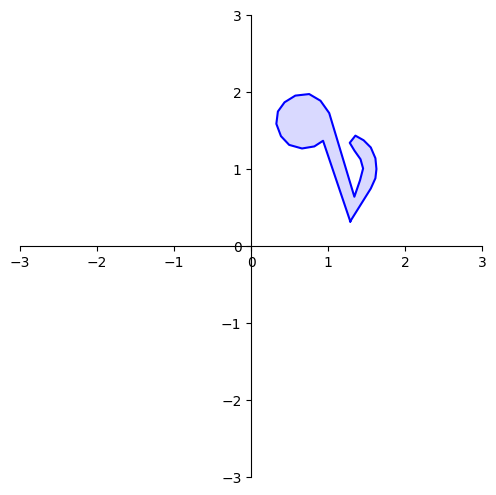

In [ ]:
#@title
dm.plotSetup()
note = dm.mnote()
dm.plotShape(note)

A imagem é representada por 26 vetores, representados na variável ``note``.

In [ ]:
note

array([[1.28666667, 0.93333333, 0.82      , 0.66      , 0.49333333,
        0.38666667, 0.32666667, 0.34666667, 0.43333333, 0.57333333,
        0.75333333, 0.9       , 1.01333333, 1.34      , 1.41333333,
        1.45333333, 1.42      , 1.34      , 1.28      , 1.35333333,
        1.46      , 1.55333333, 1.61333333, 1.62666667, 1.61333333,
        1.55333333],
       [0.31333333, 1.36      , 1.28666667, 1.26      , 1.30666667,
        1.42      , 1.58      , 1.74      , 1.86      , 1.94666667,
        1.96666667, 1.88      , 1.72      , 0.63333333, 0.84666667,
        1.        , 1.12      , 1.23333333, 1.33333333, 1.42666667,
        1.36666667, 1.27333333, 1.13333333, 0.99333333, 0.87333333,
        0.74      ]])

In [ ]:
note.shape

(2, 26)

Multiplicando $\mathbf{A}$ por ``note``, teremos o resultado da transformação linear.

In [ ]:
angle = 45

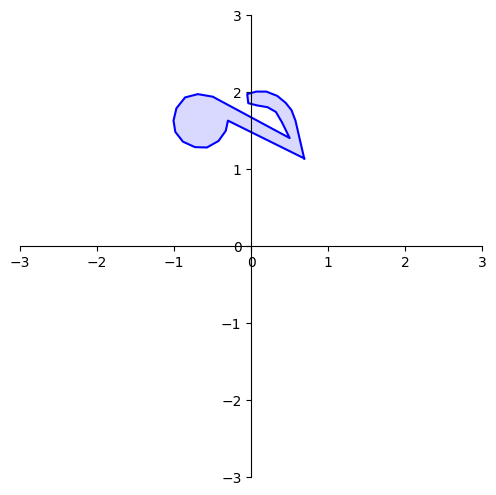

In [ ]:
#@title
dm.plotSetup()
theta = (angle/180) * np.pi
A = np.array(
    [[np.cos(theta), -np.sin(theta)],
     [np.sin(theta), np.cos(theta)]])
rnote = A @ note
dm.plotShape(rnote)

Assim, temos que essa transformação realiza a rotação!

### Exemplo IV

Considere a transformação $T(\mathbf{x}) = \mathbf{Ax}$, onde:

$$ \mathbf{A} = \left[\begin{array}{rr}r&0\\ 0&r\end{array}\right]$$
para um dado escalar $r > 0$.

O que essa Transformação faz? Vejamos o efeito no elemento representado nas figuras abaixo.


In [ ]:
r = 0.5

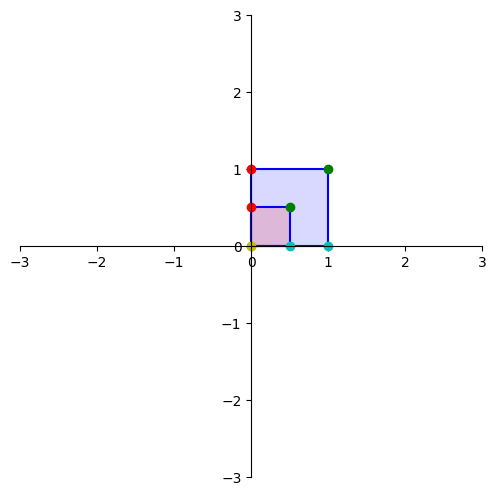

In [ ]:
#@title
square = np.array(
    [[0,1,1,0],
     [1,1,0,0]])
A = np.array(
    [[r, 0],
     [0, r]])
dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')

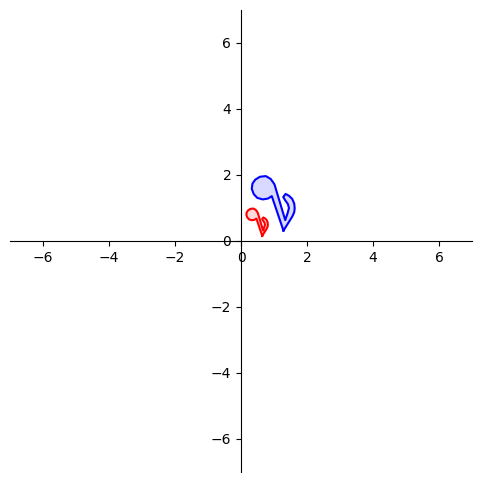

In [ ]:
#@title
dm.plotSetup(-7,7,-7, 7)
dm.plotShape(note)
dm.plotShape(A @ note,'r')

Assim, essa transformação faz a dilatação (ou contração) de vetores.

### Mais Exemplos

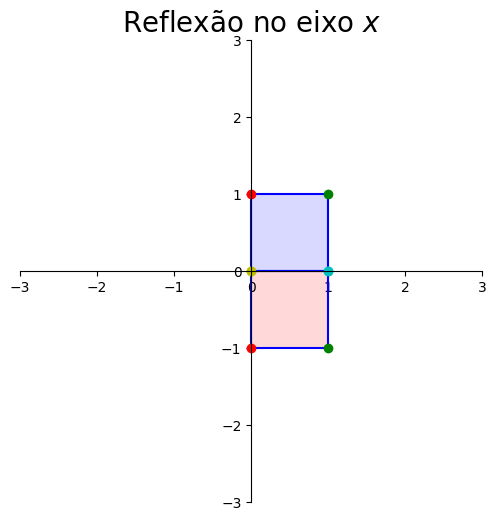

In [ ]:
#@title
A = np.array(
    [[1,  0],
     [0, -1]])
dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
plt.title(r'Reflexão no eixo $x$', size = 20);

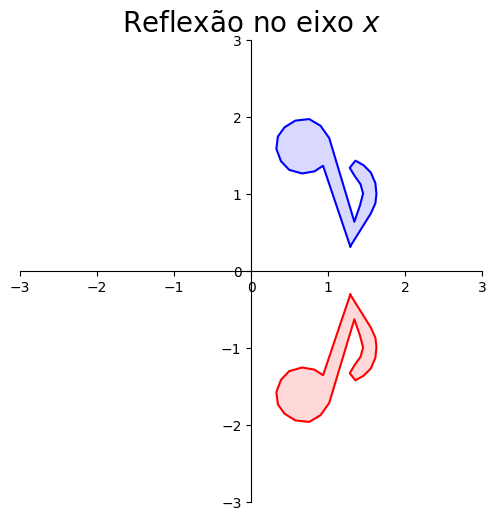

In [ ]:

#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Reflexão no eixo $x$', fontsize = 20);

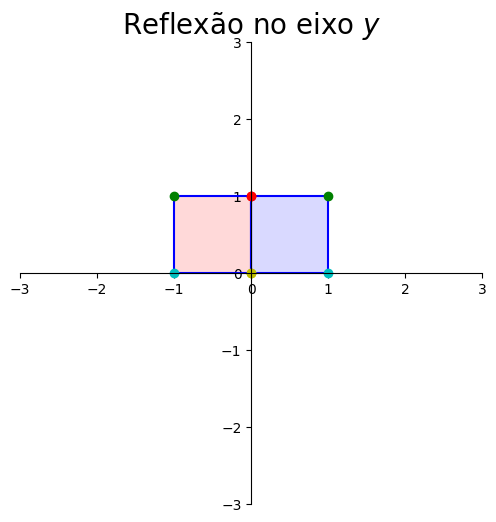

In [ ]:
#@title
A = np.array(
    [[-1,0],
     [0, 1]])
dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
plt.title(r'Reflexão no eixo $y$', size = 20);

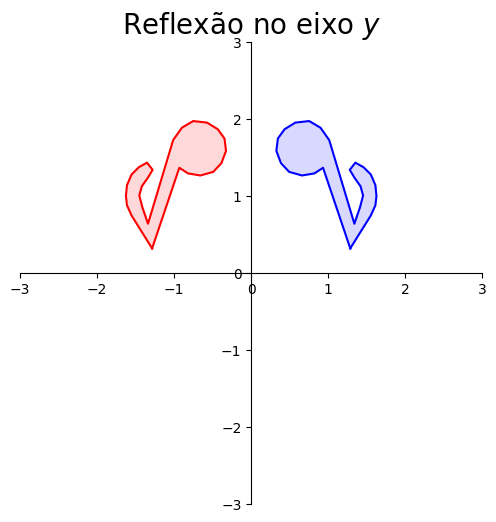

In [ ]:
#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Reflexão no eixo $y$', size = 20);

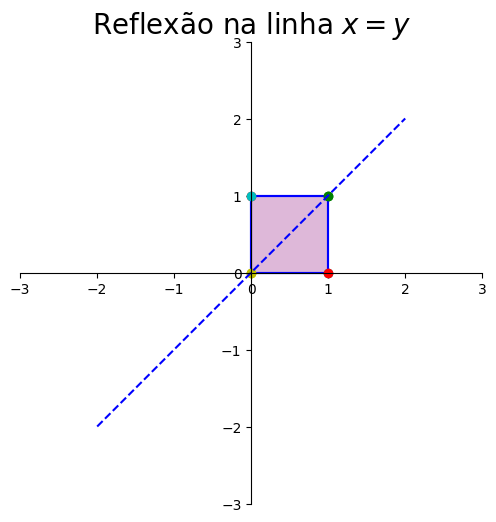

In [ ]:
#@title
A = np.array(
    [[0,1],
     [1,0]])
dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
plt.plot([-2,2],[-2,2],'b--')
plt.title(r'Reflexão na linha $x = y$', size = 20);

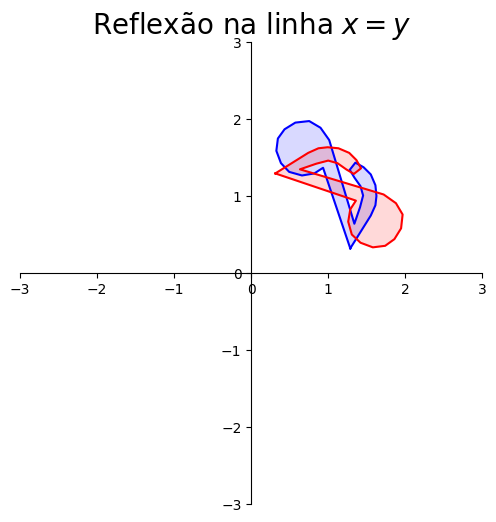

In [ ]:
#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Reflexão na linha $x = y$', size = 20);

What about reflection through the line $x_1 = -x_2$?

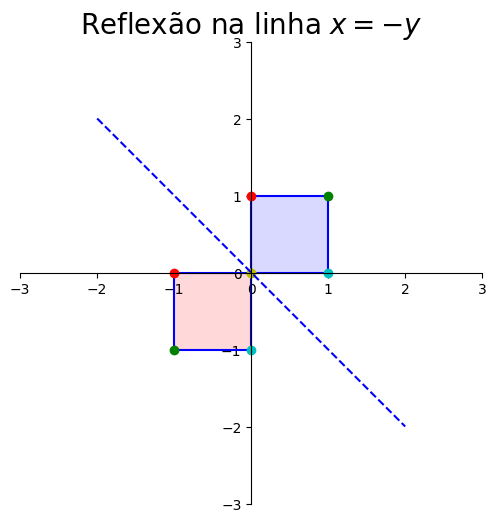

In [ ]:
#@title
A = np.array(
    [[ 0,-1],
     [-1, 0]])
dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
plt.plot([-2,2],[2,-2],'b--')
plt.title(r'Reflexão na linha $x = -y$', size = 20);

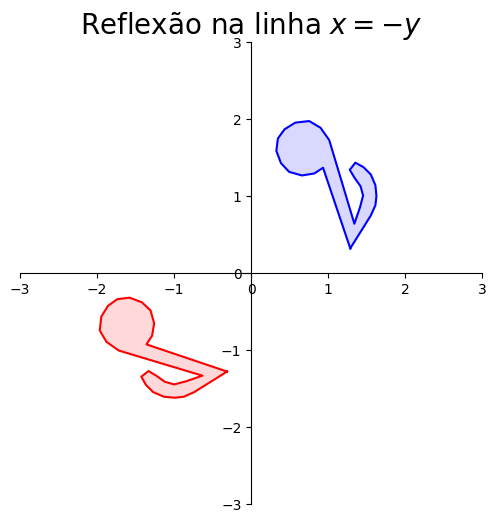

In [ ]:
#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Reflexão na linha $x = -y$', size = 20);

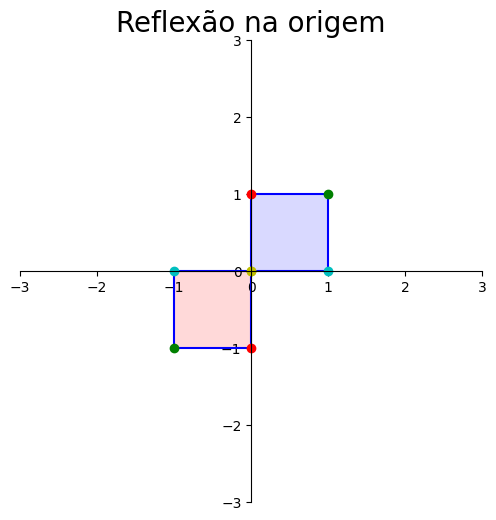

In [ ]:
#@title
A = np.array(
    [[-1, 0],
     [ 0,-1]])
ax = dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
plt.title(r'Reflexão na origem', size = 20);

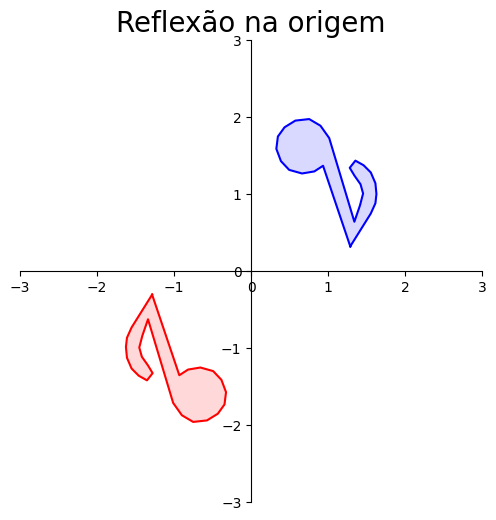

In [ ]:
#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Reflexão na origem', size = 20);

Now let's look at a particular kind of transformation called a __projection__.

Imagine we took any given point and 'dropped' it onto the $x_1$-axis.

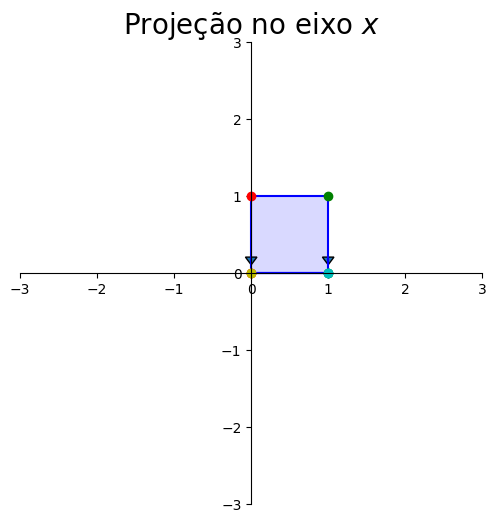

In [ ]:
#@title
A = np.array(
    [[1,0],
     [0,0]])
ax = dm.plotSetup()
dm.plotSquare(square)
dm.plotSquare(A @ square,'r')
ax.arrow(1.0,1.0,0,-0.9,head_width=0.15, head_length=0.1, length_includes_head=True)
ax.arrow(0.0,1.0,0,-0.9,head_width=0.15, head_length=0.1, length_includes_head=True)
plt.title(r'Projeção no eixo $x$', size  = 20);

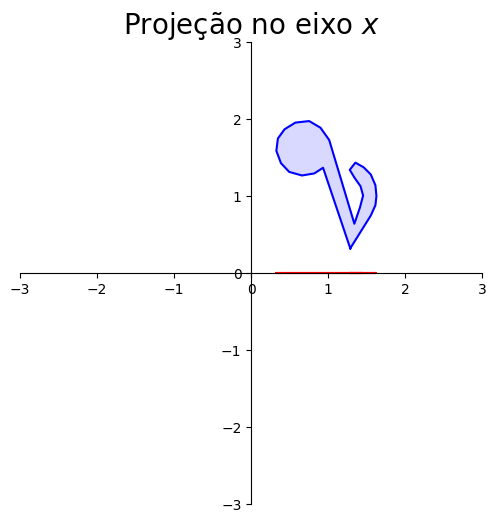

In [ ]:
#@title
dm.plotSetup()
dm.plotShape(note)
dm.plotShape(A @ note,'r')
plt.title(r'Projeção no eixo $x$', size  = 20);

## Autovalores e Autovetores

Considere uma matriz quadrada $\mathbf{A}$. Um __autovetor__ (ou __eigenvector__) de $\mathbf{A}$ é um vetor especial que __não muda de direção__ quando multiplicado por $\mathbf{A}$.


__Exemplo.__

Seja

$$ \mathbf{A} = \left[\begin{array}{rr}3 & -2\\1 & 0\end{array}\right], \quad
\mathbf{u} = \left[\begin{array}{r}-1\\1\end{array}\right], \quad
\mathbf{v} = \left[\begin{array}{r}2\\1\end{array}\right]. $$

As imagens de $\mathbf{u}$ e $\mathbf{v}$ sob multiplicação por $\mathbf{A}$ são mostradas a seguir:


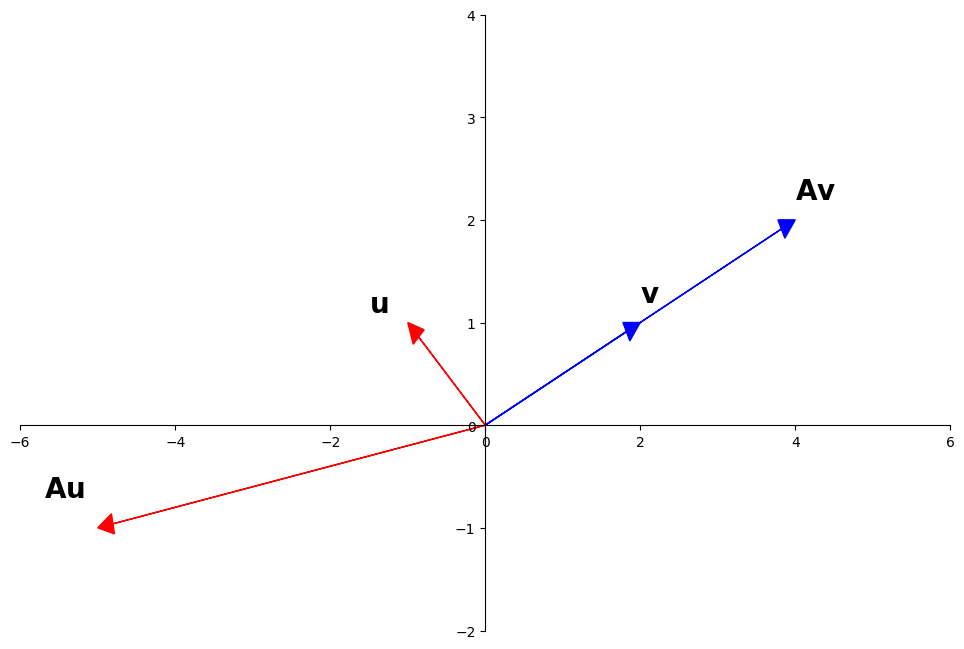

In [ ]:
#@title
ax = ut.plotSetup(size=(12,8))
ut.centerAxes(ax)
A = np.array([[3,-2],[1,0]])
u = np.array([-1,1])
v = np.array([2,1])
#
ut.plotArrowVec(ax, v, [0,0], color='Blue')
ut.plotArrowVec(ax, A.dot(v), [0,0], color='Blue')
ax.text(v[0],v[1]+0.2,r'${\bf v}$',size=20)
ax.text(A.dot(v)[0],A.dot(v)[1]+0.2,r'$\mathbf{A}{\bf v}$',size=20)
#
ut.plotArrowVec(ax, u, [0,0], color='Red')
ut.plotArrowVec(ax, A.dot(u), [0,0], color='Red')
ax.text(u[0]-0.5,u[1]+0.1,r'${\bf u}$',size=20)
ax.text(A.dot(u)[0]-0.7,A.dot(u)[1]+0.3,r'$\mathbf{A}{\bf u}$',size=20);

__Definição.__  

Um __autovetor__ de uma matriz $n\times n$ $\mathbf{A}$ é um vetor não nulo $\mathbf{x}$ tal que $\mathbf{A}\mathbf{x} = \lambda\mathbf{x}$ para algum escalar $\lambda.$  

Um escalar $\lambda$ é chamado de __autovalor__ de $\mathbf{A}$ se existir uma solução não trivial $\mathbf{x}$ de $\mathbf{A}\mathbf{x} = \lambda\mathbf{x}.$  

Tal $\mathbf{x}$ é chamado de _autovetor correspondente a $\lambda.$_


Uma matriz $n \times n$ tem no máximo $n$ autovetores distintos e no máximo $n$ autovalores distintos.

Em alguns casos, a matriz pode ser __fatorada__ usando seus autovetores e autovalores.

Isso é chamado de __diagonalização.__


Uma matriz quadrada $\mathbf{A}$ é dita __diagonalizável__ se puder ser expressa como:

$$ \mathbf{A} = \mathbf{PDP}^{-1} $$

para alguma matriz invertível $\mathbf{P}$ e alguma matriz diagonal $\mathbf{D}$.

De fato, $\mathbf{A} = \mathbf{PDP}^{-1}$, com $\mathbf{D}$ uma matriz diagonal, se e somente se as colunas de $\mathbf{P}$ forem $n$ __autovetores linearmente independentes__ de $\mathbf{A}$.  

Nesse caso, $\mathbf{D}$ contém os autovalores correspondentes de $\mathbf{A}$.


Isto é,

$$\mathbf{D} = \left[\begin{array}{cccc}\lambda_1&0&\cdots&0\\0&\lambda_2&\cdots&0\\\vdots&\vdots&\ddots&\vdots\\0&0&\cdots&\lambda_n\end{array}\right]$$

e

$$ \mathbf{P} = [\mathbf{v}_1\;\mathbf{v}_2\;\cdots\;\mathbf{v}_n].$$

Um caso especial ocorre quando $\mathbf{A}$ é __simétrica__, ou seja, $\mathbf{A} = \mathbf{A}^T$.


Nesse caso, os autovetores de $\mathbf{A}$ são todos mutuamente __ortogonais__.  

Isto é, quaisquer dois autovetores distintos têm produto interno igual a zero.


Além disso, podemos reescalar os autovetores para ter norma unitária. Nesse caso, dizemos que os autovetores são ortonormais.

Então, vamos juntar tudo.

* A diagonal de $\mathbf{D}$ contém os autovalores de $\mathbf{A}$.
* As colunas de $\mathbf{P}$ são os autovetores de $\mathbf{A}$.

Para uma matriz simétrica $\mathbf{A}$:

* colunas distintas de $\mathbf{P}$ são ortogonais
* cada coluna de $\mathbf{P}$ tem norma unitária


Portanto, descobrimos que os elementos diagonais de $\mathbf{PP}^T$ são 1, e os elementos fora da diagonal são 0.

Assim, $\mathbf{PP}^T = \mathbf{I}$.


Portanto, $\mathbf{P}^{-1} = \mathbf{P}^T.$

Assim, no caso especial de uma matriz simétrica, podemos decompor $\mathbf{A}$ como:

$$ \mathbf{A} = \mathbf{PDP}^T. $$


Esse fato incrível é conhecido como o __teorema espectral.__

Essa decomposição de $A$ é sua __decomposição espectral.__

(Os autovalores de uma matriz também são chamados de seu __espectro.__)


Esses fatos serão fundamentais para entender a __Decomposição em Valores Singulares__ (Singular Value Decomposition), que estudaremos mais adiante.

### Exemplo

In [ ]:
import numpy as np
from numpy import linalg as LA

#A = np.array([[1, 2],[3, 4]])
A = np.array([[2, 3],[3, 4]])

In [ ]:
A

array([[2, 3],
       [3, 4]])

In [ ]:
# calculando autovalores e autovetores
values, vectors = LA.eig(A)

In [ ]:
# autovalores
values

array([-0.16227766,  6.16227766])

In [ ]:
# autovetores (colunas)
vectors

array([[-0.81124219, -0.58471028],
       [ 0.58471028, -0.81124219]])

In [ ]:
# multiplicando A pelo primeiro autovetor
A @ vectors[:,0]

array([ 0.13164648, -0.09488542])

In [ ]:
# é o mesmo que multiplicar o primeiro autovalore pelo primeiro autovetor
values[0] * vectors[:,0]

array([ 0.13164648, -0.09488542])

In [ ]:
# inversa da matriz de autovetores
inv = LA.inv(vectors)
inv

array([[-0.81124219,  0.58471028],
       [-0.58471028, -0.81124219]])

In [ ]:
# transposta da matriz de autovetores
vectors.transpose()

array([[-0.81124219,  0.58471028],
       [-0.58471028, -0.81124219]])

In [ ]:
# inversa e transposta são iguais?
np.allclose(inv, vectors.transpose())

True

In [ ]:
# computando PDP^{-1}
vectors @ np.diag(values) @ inv

array([[2., 3.],
       [3., 4.]])

In [ ]:
# computando PDP^T
vectors @ np.diag(values) @ vectors.transpose()

array([[2., 3.],
       [3., 4.]])

# What is next?

Nas próximas aulas, ainda veremos outros conceitos de Álgebra Linear à medida que forem necessários. Entre eles:
- Bases
- Rank e Rank Efetivo
- Fatoração

